In [ ]:
import jax
import jax.numpy as jnp
import numpyro
from numpyro import distributions as dist
import matplotlib.pyplot as plt
import inspeqtor as sq
import optax
from numpyro.infer import SVI, TraceMeanField_ELBO
from numpyro.infer import MCMC, NUTS, Predictive, init_to_sample

In [2]:
def exponential_decay_cosine_model(t, A, B, omega_m, T2, phi):
    return A * jnp.exp(-t / T2) * jnp.cos(omega_m * t + phi) + B


# --- System Parameters ---
qubit_frequency = 5.0  # Mock qubit frequency

true_params = {
    "T2": 475.0,
    "A": 0.5,
    "B": 0.5,
    "phi": 0.2,
    "omega_m": float(jnp.pi * qubit_frequency * 0.005),
}


init_locs = {
    "T2": 500.0,
    "A": 0.8,
    "B": 0.5,
    "phi": 0.0,
    "omega_m": float(jnp.pi * qubit_frequency * 0.004),
}
init_scales = {"T2": 50.0, "A": 0.1, "B": 0.1, "phi": 0.1, "omega_m": 0.001}


def synthetic_experiment(key, t_end, shots_per_eval):
    prob = exponential_decay_cosine_model(
        t_end,
        true_params["A"],
        true_params["B"],
        true_params["omega_m"],
        true_params["T2"],
        true_params["phi"],
    )
    prob = jnp.clip(prob, 1e-5, 1.0 - 1e-5)
    return jax.random.binomial(key, n=shots_per_eval, p=prob).astype(jnp.float32)


def generate_data(sample_size, shots_per_eval):
    t_end = jnp.linspace(300, 1000, sample_size).reshape(-1, 1)
    t_start = jnp.zeros_like(t_end).reshape(-1, 1)

    t_evals = jnp.hstack([t_start, t_end])

    population = synthetic_experiment(jax.random.key(0), t_end, shots_per_eval)
    # Bugfix: Return counts directly instead of converting to proportions
    return t_evals, population.flatten()

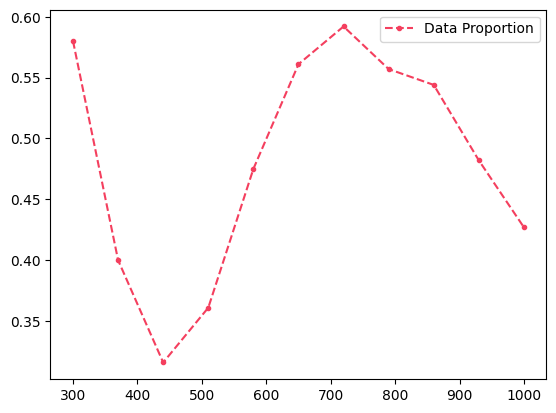

In [3]:
shots = 1000

full_t_evals, full_population = generate_data(201, shots)
t_evals, experimental_population = generate_data(11, shots)
t_end = t_evals[:, 1]
population = experimental_population

# Plot as a proportion:
plt.plot(
    t_end.reshape(-1),
    population / shots,
    ".--",
    color=sq.utils.colors.red,
    label="Data Proportion",
)
plt.legend()

In [4]:
def make_model(prior_locs, prior_scales, shots_per_eval):
    def model(t_evals):
        T2 = numpyro.sample("T2", dist.Normal(prior_locs["T2"], prior_scales["T2"]))
        A = numpyro.sample("A", dist.Normal(prior_locs["A"], prior_scales["A"]))
        B = numpyro.sample("B", dist.Normal(prior_locs["B"], prior_scales["B"]))
        phi = numpyro.sample("phi", dist.Normal(prior_locs["phi"], prior_scales["phi"]))
        omega_m = numpyro.sample(
            "omega_m", dist.Normal(prior_locs["omega_m"], prior_scales["omega_m"])
        )

        t_end = t_evals[..., 1]

        prob_minus = exponential_decay_cosine_model(t_end, A, B, omega_m, T2, phi)
        prob_minus = jnp.clip(prob_minus, 1e-5, 1.0 - 1e-5)

        with numpyro.plate_stack("plate", sizes=t_evals.shape[:-1]):
            numpyro.sample(
                "shots",
                dist.BinomialProbs(total_count=shots_per_eval, probs=prob_minus),
                infer={"enumerate": "parallel"},
            )

    return model


def mcmc_inference(init_locs, init_scales, shots, population, t_evals):
    model = make_model(init_locs, init_scales, shots)
    conditioned_model = numpyro.handlers.condition(model, data={"shots": population})

    mcmc = MCMC(
        NUTS(conditioned_model, init_strategy=init_to_sample),
        num_warmup=1000,
        num_samples=1000,
    )
    mcmc.run(jax.random.key(0), t_evals)
    mcmc.print_summary()
    return mcmc.get_samples()


def make_boed_guide(locs_dict, scales_dict):
    def boed_guide(t_evals):
        locs = {}
        scales = {}
        for k in locs_dict.keys():
            locs[k] = numpyro.param(f"posterior_{k}_loc", jnp.array(locs_dict[k]))
            scales[k] = numpyro.param(
                f"posterior_{k}_scale",
                jnp.array(scales_dict[k]),
                constraint=dist.constraints.positive,
            )
            numpyro.sample(k, dist.Normal(locs[k], scales[k]))

    return boed_guide


def svi_inference(
    key, init_locs, init_scales, shots, population, t_evals, progress_bar=True
):
    base_model = make_model(init_locs, init_scales, shots)
    conditioned_model = numpyro.handlers.condition(
        base_model, data={"shots": population}
    )
    svi_optimizer = numpyro.optim.optax_to_numpyro(optax.adam(0.01))

    current_guide = make_boed_guide(init_locs, init_scales)
    svi = SVI(
        model=conditioned_model,
        guide=current_guide,
        optim=svi_optimizer,
        loss=TraceMeanField_ELBO(num_particles=1),
    )

    NUM_STEP_SVI = 2000

    key, subkey = jax.random.split(key)
    svi_results = svi.run(subkey, NUM_STEP_SVI, t_evals, progress_bar=progress_bar)

    key, subkey = jax.random.split(key)

    predictive_samples = Predictive(
        base_model, guide=current_guide, params=svi_results.params, num_samples=1000
    )(subkey, full_t_evals)

    return predictive_samples, svi_results.params

In [5]:
uniform_samples, uniform_svi_params = svi_inference(
    jax.random.key(0),
    init_locs,
    init_scales,
    shots,
    population,
    t_evals,
    # jax.random.key(0), init_locs, init_scales, shots, full_population, full_t_evals
)

uniform_population_samples = uniform_samples["shots"]

100%|██████████| 2000/2000 [00:00<00:00, 3075.48it/s, init loss: 5411.0249, avg. loss [1901-2000]: 230.8290]


In [6]:
# # uniform_samples = mcmc_inference(init_locs, init_scales, shots, population, t_evals)
# uniform_samples = mcmc_inference(init_locs, init_scales, shots, full_population, full_t_evals)
# uniform_population_samples = Predictive(
#     make_model(init_locs, init_scales, shots), posterior_samples=uniform_samples
# )(jax.random.key(0), full_t_evals)["shots"]

In [7]:
true_population = (
    exponential_decay_cosine_model(
        full_t_evals[:, 1],
        true_params["A"],
        true_params["B"],
        true_params["omega_m"],
        true_params["T2"],
        true_params["phi"],
    )
    * shots
)

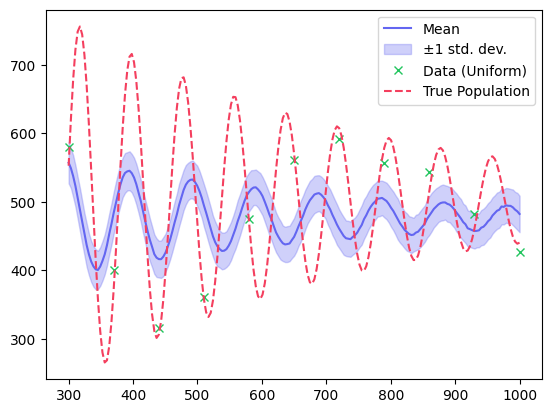

In [8]:
mean_pred = jnp.mean(uniform_population_samples, axis=0)
std_pred = jnp.std(uniform_population_samples, axis=0)

plt.plot(full_t_evals[:, 1], mean_pred, "-", label="Mean", color=sq.utils.colors.blue)
plt.fill_between(
    full_t_evals[:, 1],
    mean_pred - std_pred,
    mean_pred + std_pred,
    color=sq.utils.colors.blue,
    alpha=0.3,
    label="±1 std. dev.",
)

plt.plot(
    t_evals[:, 1],
    population,
    "x",
    label="Data (Uniform)",
    color=sq.utils.colors.green,
)

plt.plot(
    full_t_evals[:, 1],
    true_population,
    "--",
    color=sq.utils.colors.red,
    label="True Population",
)

plt.legend()

In [ ]:
import jax.numpy as jnp


def simple_marginal_guide(t_evals, observation_labels, target_labels):
    """
    The simplest possible marginal guide.
    Completely eliminates the neural network layers.
    """
    # 1. Grab the number of candidate designs you are testing.
    # If t_evals shape is (num_particles, num_candidates, feature_dim),
    # then axis -2 represents the candidate pool size.
    num_candidates = t_evals.shape[-2]

    # 2. Directly declare the probabilities as variational parameters (phi).
    # We initialize them all to 0.5. The constraint ensures the optimizer
    # keeps them strictly between 1e-5 and 1.0 (mirroring your model's clip).
    q_probs = numpyro.param(
        "phi_probs",
        0.5 * jnp.ones((num_candidates,)),
        constraint=dist.constraints.interval(1e-5, 1.0 - 1e-5),
    )

    # 3. Mirror the plate structure and sample using dist.BinomialProbs
    # shots_per_eval can be hardcoded here if you are keeping it constant.
    with numpyro.plate_stack("plate", sizes=t_evals.shape[:-1]):
        numpyro.sample("shots", dist.BinomialProbs(total_count=1000, probs=q_probs))

## BOED

In [10]:
t_end_candidates = jnp.linspace(300, 1000, 200).reshape(-1, 1)
t_start_candidates = jnp.zeros_like(t_end_candidates)
candidate_designs = jnp.hstack([t_start_candidates, t_end_candidates])

history = [(init_locs, init_scales)]

shots_per_eval = 1000

base_model = make_model(init_locs, init_scales, shots_per_eval)
current_model = make_model(init_locs, init_scales, shots_per_eval)

all_t_evals = jnp.empty((0, 2))
all_y = jnp.empty((0,))

key = jax.random.key(0)

rounds = 10
NUM_STEP_EIG = 100
NUM_STEP_SVI = 2000
eig_history = []

print("Iterative BOED for T2, A, B, phi, omega_m\n" + "-" * 45)

current_locs = init_locs.copy()
current_scales = init_scales.copy()

amortiazed_marginal_guide = simple_marginal_guide

for experiment in range(rounds):
    key, subkey = jax.random.split(key)

    # marginal_guide = simple_marginal_guide(
    #     current_model, candidate_designs
    # )
    optimizer = sq.optimize.get_default_optimizer(NUM_STEP_EIG)

    eig, aux = sq.boed.estimate_eig(
        subkey,
        current_model,
        # marginal_guide,
        amortiazed_marginal_guide,
        candidate_designs,
        observation_labels=["shots"],
        target_labels=["T2", "A", "B", "phi", "omega_m"],
        num_particles=200,
        num_optimization_steps=NUM_STEP_EIG,
        optimizer=optimizer,
        final_num_particles=2000,
    )

    eig_history.append(eig)

    best_idx = int(jnp.argmax(eig))
    chosen_design = candidate_designs[best_idx]
    chosen_t_end = chosen_design[1]

    key, subkey = jax.random.split(key)
    y_obs = synthetic_experiment(subkey, chosen_t_end, shots_per_eval)

    all_t_evals = jnp.vstack([all_t_evals, chosen_design])
    all_y = jnp.append(all_y, y_obs)

    print(f"Round {experiment + 1:2d}: Chosen t = {chosen_t_end:5.1f} ns")

    conditioned_model = numpyro.handlers.condition(base_model, {"shots": all_y})

    svi_optimizer = numpyro.optim.optax_to_numpyro(optax.adam(0.01))

    current_guide = make_boed_guide(current_locs, current_scales)
    svi = SVI(
        model=conditioned_model,
        guide=current_guide,
        optim=svi_optimizer,
        loss=TraceMeanField_ELBO(num_particles=1),
    )

    key, subkey = jax.random.split(key)
    svi_results = svi.run(subkey, NUM_STEP_SVI, all_t_evals, progress_bar=True)

    new_locs = {
        k: svi_results.params[f"posterior_{k}_loc"].item() for k in init_locs.keys()
    }
    new_scales = {
        k: svi_results.params[f"posterior_{k}_scale"].item() for k in init_scales.keys()
    }

    history.append((new_locs, new_scales))

    # Advance the current posterior logic for the next loops
    current_locs = new_locs
    current_scales = new_scales

    # Add a floor to the design scales to avoid premature collapse and numerical issues when calculating EIG
    # design_scales = {k: max(new_scales[k], 1e-4) for k in new_scales.keys()}
    current_model = make_model(new_locs, new_scales, shots_per_eval)

    # Print all parameters
    print(
        f"           Estimated T2 = {new_locs['T2']:5.1f} ± {new_scales['T2']:4.1f} ns"
    )
    print(f"           Estimated A  = {new_locs['A']:5.2f} ± {new_scales['A']:4.2f}")
    print(f"           Estimated B  = {new_locs['B']:5.2f} ± {new_scales['B']:4.2f}")
    print(
        f"           Estimated phi= {new_locs['phi']:5.2f} ± {new_scales['phi']:4.2f}"
    )
    print(
        f"           Estimated omg= {new_locs['omega_m']:5.4f} ± {new_scales['omega_m']:4.4f}"
    )

Iterative BOED for T2, A, B, phi, omega_m
---------------------------------------------
Round  1: Chosen t = 310.6 ns


100%|██████████| 2000/2000 [00:00<00:00, 2576.10it/s, init loss: 14.6795, avg. loss [1901-2000]: 30.8123]


           Estimated T2 = 498.9 ± 39.8 ns
           Estimated A  =  0.29 ± 0.06
           Estimated B  =  0.61 ± 0.04
           Estimated phi= -0.06 ± 0.10
           Estimated omg= 0.0636 ± 0.0006
Round  2: Chosen t = 328.1 ns


100%|██████████| 2000/2000 [00:00<00:00, 3257.05it/s, init loss: 24.2571, avg. loss [1901-2000]: 34.0183]


           Estimated T2 = 491.3 ± 34.9 ns
           Estimated A  =  0.36 ± 0.02
           Estimated B  =  0.55 ± 0.01
           Estimated phi= -0.06 ± 0.07
           Estimated omg= 0.0613 ± 0.0003
Round  3: Chosen t = 489.9 ns


...

           Estimated T2 = 462.8 ± 22.4 ns
           Estimated A  =  0.51 ± 0.02
           Estimated B  =  0.49 ± 0.01
           Estimated phi=  0.39 ± 0.04
           Estimated omg= 0.0781 ± 0.0001
Round  9: Chosen t = 303.5 ns


100%|██████████| 2000/2000 [00:00<00:00, 3146.51it/s, init loss: 183.2366, avg. loss [1901-2000]: 201.4862]


           Estimated T2 = 461.2 ± 19.1 ns
           Estimated A  =  0.49 ± 0.02
           Estimated B  =  0.51 ± 0.00
           Estimated phi=  0.39 ± 0.03
           Estimated omg= 0.0780 ± 0.0001
Round 10: Chosen t = 310.6 ns


100%|██████████| 2000/2000 [00:00<00:00, 3205.32it/s, init loss: 192.0621, avg. loss [1901-2000]: 203.5525]


           Estimated T2 = 459.9 ± 16.2 ns
           Estimated A  =  0.47 ± 0.02
           Estimated B  =  0.51 ± 0.00
           Estimated phi=  0.39 ± 0.03
           Estimated omg= 0.0783 ± 0.0001


In [11]:
boed_population = Predictive(
    base_model, guide=current_guide, params=svi_results.params, num_samples=1000
)(jax.random.key(0), full_t_evals[:, 1].reshape(-1, 1))["shots"]

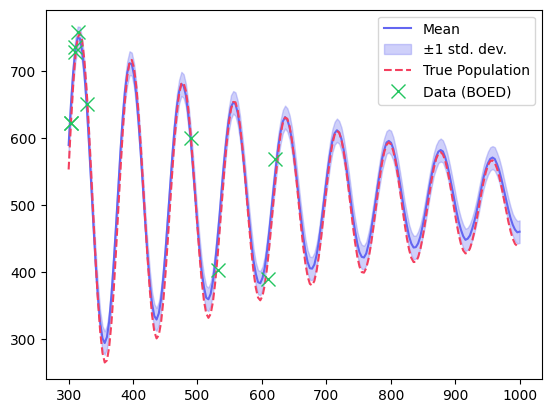

In [12]:
mean_pred = jnp.mean(boed_population, axis=0)
std_pred = jnp.std(boed_population, axis=0)

plt.plot(full_t_evals[:, 1], mean_pred, "-", label="Mean", color=sq.utils.colors.blue)
plt.fill_between(
    full_t_evals[:, 1],
    mean_pred - std_pred,
    mean_pred + std_pred,
    color=sq.utils.colors.blue,
    alpha=0.3,
    label="±1 std. dev.",
)


plt.plot(
    full_t_evals[:, 1],
    true_population,
    "--",
    color=sq.utils.colors.red,
    label="True Population",
)

plt.plot(
    all_t_evals[:, 1],
    all_y,
    "x",
    markersize=10,
    label="Data (BOED)",
    color=sq.utils.colors.green,
)

plt.legend()

## Compare BOED with SVI results

In [13]:
uniform_samples_res_mean = {
    k: uniform_svi_params[f"posterior_{k}_loc"].item() for k in init_locs.keys()
}
uniform_samples_res_std = {
    k: uniform_svi_params[f"posterior_{k}_scale"].item() for k in init_scales.keys()
}

boed_res_mean = new_locs
boed_res_std = new_scales

print(
    f"{'Parameter':<10} | {'True Value':<12} | {'Uniform Estimated':<25} | {'BOED Estimated':<25}"
)
print("-" * 82)
for key, value in true_params.items():
    uniform_str = (
        f"{uniform_samples_res_mean[key]:.4f} ± {uniform_samples_res_std[key]:.4f}"
    )
    boed_str = f"{boed_res_mean[key]:.4f} ± {boed_res_std[key]:.4f}"
    print(f"{key:<10} | {value:<12.4f} | {uniform_str:<25} | {boed_str:<25}")

Parameter  | True Value   | Uniform Estimated         | BOED Estimated           
----------------------------------------------------------------------------------
T2         | 475.0000     | 498.4483 ± 40.5049        | 459.8532 ± 16.1926       
A          | 0.5000       | 0.1588 ± 0.0296           | 0.4743 ± 0.0150          
B          | 0.5000       | 0.4772 ± 0.0184           | 0.5125 ± 0.0045          
phi        | 0.2000       | -0.0881 ± 0.0847          | 0.3874 ± 0.0252          
omega_m    | 0.0785       | 0.0641 ± 0.0007           | 0.0783 ± 0.0001          


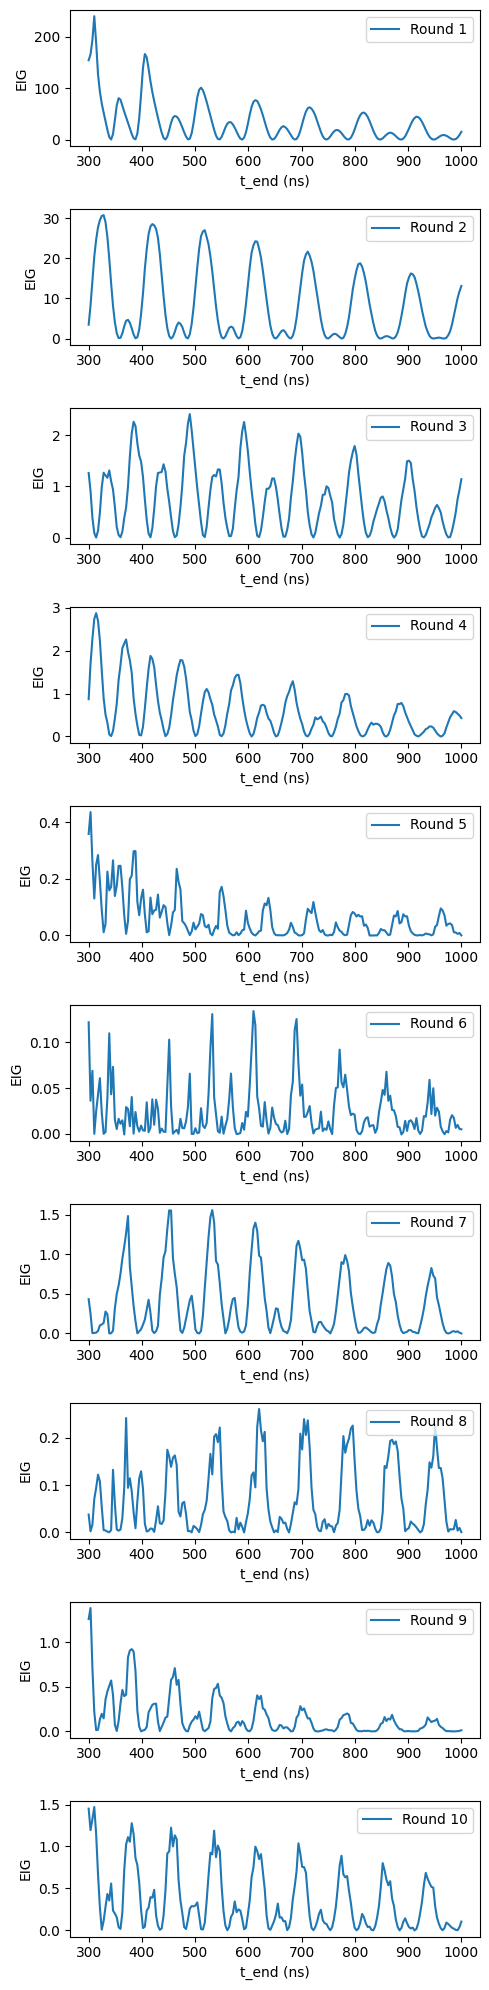

In [14]:
# Plot the EIG history
fig, axes = plt.subplots(len(eig_history), 1, figsize=(5, 2 * len(eig_history)))
for i, eig in enumerate(eig_history):
    axes[i].plot(candidate_designs[:, 1], eig, label=f"Round {i + 1}")
    axes[i].set_xlabel("t_end (ns)")
    axes[i].set_ylabel("EIG")
    axes[i].legend()
plt.tight_layout()
plt.show()

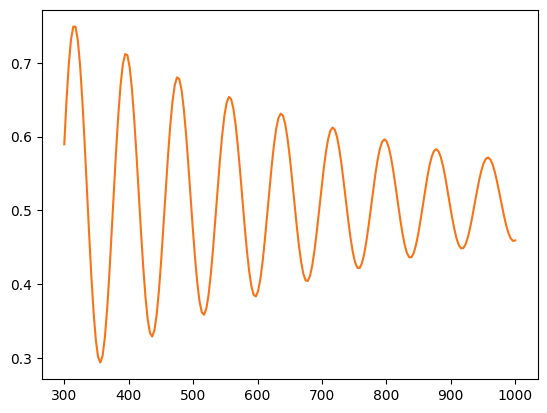

In [15]:
y = exponential_decay_cosine_model(
    full_t_evals[:, 1],
    new_locs["A"],
    new_locs["B"],
    new_locs["omega_m"],
    new_locs["T2"],
    new_locs["phi"],
)
plt.plot(full_t_evals[:, 1], y, label="BOED Fit", color=sq.utils.colors.orange)

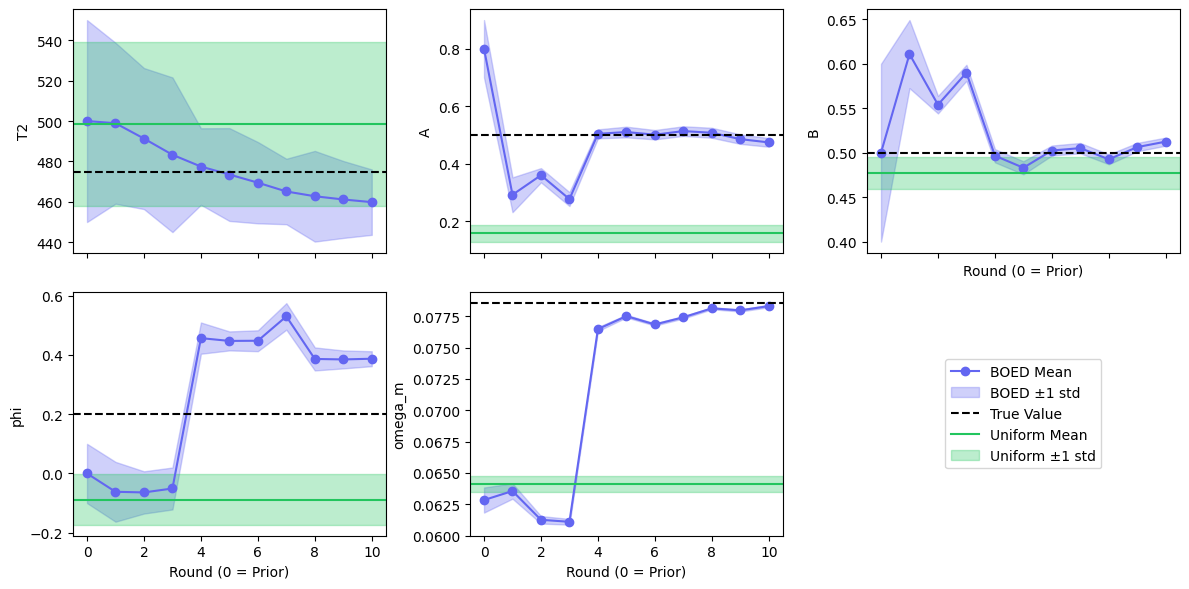

In [16]:
num_params = len(true_params)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)

rounds_idx = range(len(history))

for i, param in enumerate(true_params.keys()):
    ax = axes[i // 3, i % 3]

    # Extract historical BOED means and stds for this parameter
    boed_means = [h[0][param] for h in history]
    boed_stds = [h[1][param] for h in history]

    # Plot BOED progression
    ax.plot(rounds_idx, boed_means, "o-", color=sq.utils.colors.blue, label="BOED Mean")
    # Use fill_between by converting to list of floats (numpy handles this fine)
    ax.fill_between(
        rounds_idx,
        [m - s for m, s in zip(boed_means, boed_stds)],
        [m + s for m, s in zip(boed_means, boed_stds)],
        color=sq.utils.colors.blue,
        alpha=0.3,
        label="BOED ±1 std",
    )

    # Plot true value
    ax.axhline(true_params[param], color="black", linestyle="--", label="True Value")

    # Plot uniform estimation
    uni_mean = uniform_samples_res_mean[param]
    uni_std = uniform_samples_res_std[param]
    ax.axhline(
        uni_mean, color=sq.utils.colors.green, linestyle="-", label="Uniform Mean"
    )
    ax.axhspan(
        uni_mean - uni_std,
        uni_mean + uni_std,
        color=sq.utils.colors.green,
        alpha=0.3,
        label="Uniform ±1 std",
    )

    ax.set_ylabel(param)

    if i >= 2:
        ax.set_xlabel("Round (0 = Prior)")
    else:
        # For the top right plot (index 2), we want x-ticks since there's no plot below it
        if i == 2:
            ax.xaxis.set_tick_params(labelbottom=True)
            ax.set_xlabel("Round (0 = Prior)")

# Use the last subplot for the legend
ax_legend = axes[1, 2]
ax_legend.axis("off")

handles, labels = axes[0, 0].get_legend_handles_labels()
ax_legend.legend(handles, labels, loc="center")

plt.tight_layout()
plt.show()

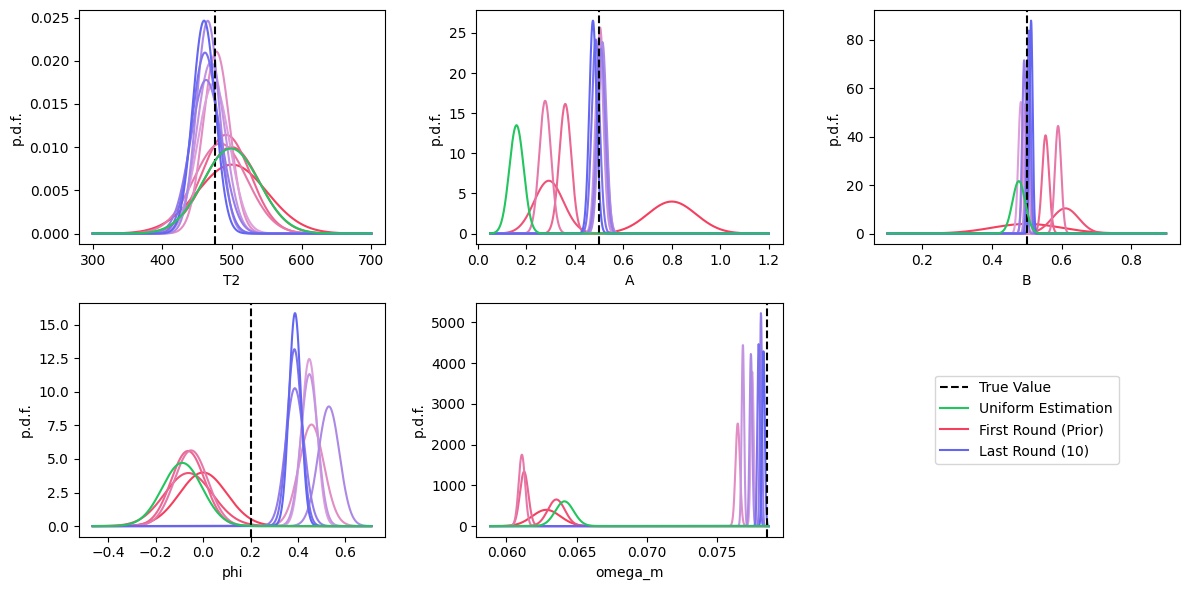

In [ ]:
from jax.scipy.stats import norm
import matplotlib.colors as colors
import matplotlib.cm as cmx
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

num_params = len(true_params)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=False)

# A direct RGB interpolation between red and blue often creates a dark, muddy purple in the middle.
# Adding a lighter midpoint like 'plum' (a soft purple) smooths out the luminance transition.
cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", [sq.utils.colors.red, "plum", sq.utils.colors.blue]
)
cNorm = colors.Normalize(vmin=0, vmax=len(history) - 1)
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=cmap)

for i, param in enumerate(true_params.keys()):
    ax = axes[i // 3, i % 3]

    # Calculate sensible bounds for the x-axis
    all_means = [h[0][param] for h in history]
    all_stds = [h[1][param] for h in history]
    x_min = min([float(m - 4 * s) for m, s in zip(all_means, all_stds)])
    x_max = max([float(m + 4 * s) for m, s in zip(all_means, all_stds)])

    x = jnp.linspace(x_min, x_max, 1000)

    for idx, (locs, scales) in enumerate(history):
        color = scalarMap.to_rgba(idx)
        y = norm.pdf(x, locs[param], scales[param])
        ax.plot(x, y, color=color)

    ax.axvline(true_params[param], color="black", linestyle="--", label="True Value")

    # Plot uniform
    uni_mean = uniform_samples_res_mean[param]
    uni_std = uniform_samples_res_std[param]
    y_uni = norm.pdf(x, uni_mean, uni_std)
    ax.plot(
        x, y_uni, color=sq.utils.colors.green, linestyle="-", label="Uniform Estimation"
    )

    ax.set_xlabel(f"{param}")
    ax.set_ylabel("p.d.f.")

# Use the last subplot for the legend
ax_legend = axes[1, 2]
ax_legend.axis("off")

# Extract handles from the last plotted axis
handles, labels = ax.get_legend_handles_labels()
first_color = scalarMap.to_rgba(0)
last_color = scalarMap.to_rgba(len(history) - 1) # type: ignore
handles.extend(
    [
        Line2D([0], [0], color=first_color, label="First Round (Prior)"), # type: ignore
        Line2D([0], [0], color=last_color, label=f"Last Round ({len(history) - 1})"), # type: ignore
    ]
)
ax_legend.legend(handles=handles, loc="center")

plt.tight_layout()
plt.show()